In [9]:
# Fit and actual gaussian copular and compare with heuristic amplifier

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy import stats

data_path =  os.path.expanduser("~/Desktop/SentriVaR-500/data")

# load saved data
prices = pd.read_csv(f"{data_path}/prices.csv", index_col="Date", parse_dates=True)
regime = pd.read_csv(f"{data_path}/regime_states.csv", parse_dates=["date"]).set_index("date")

returns = prices.pct_change().dropna()
returns = returns.join(regime[["regime", "regime_label"]], how="inner")

print("Loaded")
print(f"Returns + regime: {returns.shape}")
print(returns.head())

Loaded
Returns + regime: (2115, 7)
                AAPL     GOOGL       JPM      MSFT      SOXX  regime  \
Date                                                                   
2018-01-31  0.002755  0.004120  0.004865  0.024477  0.008143       2   
2018-02-01  0.002090 -0.000533  0.010374 -0.007894 -0.004933       2   
2018-02-02 -0.043390 -0.052802 -0.022162 -0.026310 -0.026912       1   
2018-02-05 -0.024984 -0.050759 -0.047952 -0.041185 -0.047083       1   
2018-02-06  0.041792  0.020746  0.030423  0.037841  0.036191       1   

           regime_label  
Date                     
2018-01-31       Crisis  
2018-02-01       Crisis  
2018-02-02     Elevated  
2018-02-05     Elevated  
2018-02-06     Elevated  


In [11]:
# Transform returns to pseudo observations
TICKERS = ["AAPL", "GOOGL", "JPM", "MSFT", "SOXX"]

def to_pseudo_obs(data):
    """
    Convert raw returns into pseudo-observations in (0,1) using
    the empirical CDF (rank / (n+1)).
    """
    n = len(data)
    pseudo = data.rank(method="average") / (n + 1)
    return pseudo

pseudo_obs = returns[TICKERS].apply(to_pseudo_obs)

print("Pseudo-observations (should all be in (0,1)):")
print(pseudo_obs.describe())

Pseudo-observations (should all be in (0,1)):
              AAPL        GOOGL          JPM         MSFT         SOXX
count  2115.000000  2115.000000  2115.000000  2115.000000  2115.000000
mean      0.500000     0.500000     0.500000     0.500000     0.500000
std       0.288607     0.288607     0.288607     0.288607     0.288607
min       0.000473     0.000473     0.000473     0.000473     0.000473
25%       0.250236     0.250236     0.250236     0.250236     0.250236
50%       0.500000     0.500000     0.500000     0.500000     0.500000
75%       0.749764     0.749764     0.749764     0.749764     0.749764
max       0.999527     0.999527     0.999527     0.999527     0.999527


In [12]:
# Transform pseudo_ob servatio  into Gaussian copula space via the inverse standard normal CDF

gaussian_space = pseudo_obs.apply(stats.norm.ppf)
gaussian_space["regime"] = returns["regime"].values
gaussian_space["regime_label"] = returns["regime_label"].values

print("Gaussian Copula Space:")
print(gaussian_space[TICKERS].describe())

# FIt the correlation matrix seperately per regime
copula_corr = {}
for regime_val, label in {0: "Normal", 1: "Elevated", 2: "Crisis"}.items():
    subset = gaussian_space[gaussian_space["regime"] == regime_val][TICKERS]
    copula_corr[label] = subset.corr()
    print(f"\n{label} regime — Gaussian copula correlation matrix:")
    print(copula_corr[label].round(3))

Gaussian Copula Space:
               AAPL         GOOGL           JPM          MSFT          SOXX
count  2.115000e+03  2.115000e+03  2.115000e+03  2.115000e+03  2.115000e+03
mean   1.537932e-10  1.356397e-11  4.115859e-10  2.934396e-10  5.879934e-10
std    9.970700e-01  9.970700e-01  9.970700e-01  9.970700e-01  9.970700e-01
min   -3.306356e+00 -3.306356e+00 -3.306356e+00 -3.306356e+00 -3.306356e+00
25%   -6.737465e-01 -6.737465e-01 -6.737465e-01 -6.737465e-01 -6.737465e-01
50%    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
75%    6.737465e-01  6.737465e-01  6.737465e-01  6.737465e-01  6.737465e-01
max    3.306356e+00  3.306356e+00  3.306356e+00  3.306356e+00  3.306356e+00

Normal regime — Gaussian copula correlation matrix:
        AAPL  GOOGL    JPM   MSFT   SOXX
AAPL   1.000  0.441  0.264  0.462  0.451
GOOGL  0.441  1.000  0.235  0.487  0.412
JPM    0.264  0.235  1.000  0.198  0.337
MSFT   0.462  0.487  0.198  1.000  0.445
SOXX   0.451  0.412  0.337  0.445  

Average pairwise Gaussian copula correlation by regime: 
  Normal    : 0.3733
  Elevated  : 0.4985
  Crisis    : 0.6686


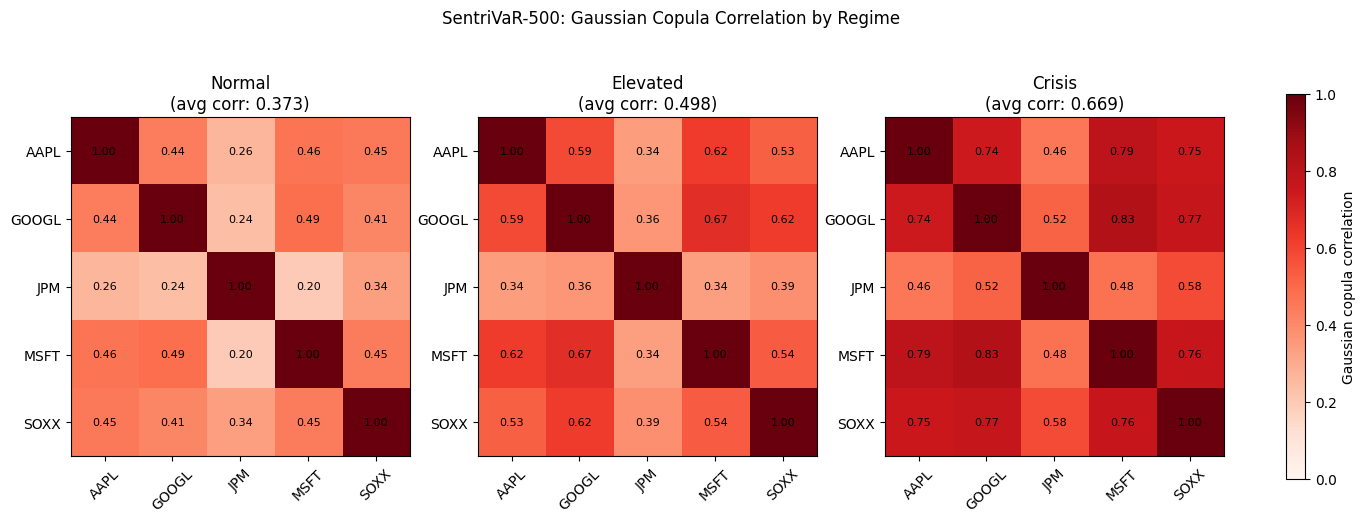

Saved: copula_formal_correlation.png


In [15]:
# summarize average off-diagonal correlation per regime
def avg_offdiag_corr(corr_matrix):
    mask = np.ones(corr_matrix.shape, dtype = bool)
    np.fill_diagonal(mask, False)
    return corr_matrix.values[mask].mean()

print("Average pairwise Gaussian copula correlation by regime: ")

for label, corr_matrix in copula_corr.items():
    avg_corr = avg_offdiag_corr(corr_matrix)
    print(f"  {label:10s}: {avg_corr:.4f}")

# Visualize the three correlation matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (label, corr_matrix) in zip(axes, copula_corr.items()):
    im = ax.imshow(corr_matrix.values, vmin=0, vmax=1, cmap="Reds")
    ax.set_xticks(range(len(TICKERS)))
    ax.set_yticks(range(len(TICKERS)))
    ax.set_xticklabels(TICKERS, rotation=45)
    ax.set_yticklabels(TICKERS)
    ax.set_title(f"{label}\n(avg corr: {avg_offdiag_corr(corr_matrix):.3f})")
    for i in range(len(TICKERS)):
        for j in range(len(TICKERS)):
            ax.text(j, i, f"{corr_matrix.values[i,j]:.2f}",
                    ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=axes, fraction=0.02, label="Gaussian copula correlation")
plt.suptitle("SentriVaR-500: Gaussian Copula Correlation by Regime", y=1.05)
plt.savefig(f"{data_path}/copula_formal_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: copula_formal_correlation.png")

In [16]:
# Compare formal copula correlation with heuristic amplification
vix_factor_ratio = avg_offdiag_corr(copula_corr["Crisis"]) / avg_offdiag_corr(copula_corr["Normal"])
print(f"Crisis / Normal correlation ratio: {vix_factor_ratio:.3f}")
print(f"(This is the empirical justification for using a > 1 exponential amplifier")
print(f" in the Crisis regime of the heuristic Copula risk amplifier — see 07_copula_risk.ipynb)")

# Save summary for README / reference
summary = pd.DataFrame({
    "Regime": ["Normal", "Elevated", "Crisis"],
    "Avg_Copula_Correlation": [avg_offdiag_corr(copula_corr[l]) for l in ["Normal", "Elevated", "Crisis"]]
})
summary.to_csv(f"{data_path}/copula_formal_summary.csv", index=False)
print("\nSaved: copula_formal_summary.csv")
print(summary)


Crisis / Normal correlation ratio: 1.791
(This is the empirical justification for using a > 1 exponential amplifier
 in the Crisis regime of the heuristic Copula risk amplifier — see 07_copula_risk.ipynb)

Saved: copula_formal_summary.csv
     Regime  Avg_Copula_Correlation
0    Normal                0.373255
1  Elevated                0.498460
2    Crisis                0.668629


In [17]:
print("All outputs saved:")
print("  copula_formal_correlation.png")
print("  copula_formal_summary.csv")

All outputs saved:
  copula_formal_correlation.png
  copula_formal_summary.csv
